In [1]:
import pandas as pd
from table_utils import (
    axis_value_counts_table,
    cross_axis_percent_table,
    top_within_axis_overlaps,
)

validated_misalignments = pd.read_json("../data/core/validated_misalignments.json")
annotated_misalignments = pd.read_json("../data/core/annotated_misalignments.json")
session_mapping = pd.read_json("../data/core/session_mapping.json")

In [2]:
annotated_misalignments["n_symptoms"] = annotated_misalignments[
    ["S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8"]
].apply(lambda x: x.sum(), axis=1)
annotated_misalignments["n_causes"] = annotated_misalignments[
    ["C1", "C2", "C3", "C4", "C5", "C6", "C7"]
].apply(lambda x: x.notna().sum(), axis=1)

display(
    axis_value_counts_table(annotated_misalignments, "n_symptoms"),
    axis_value_counts_table(annotated_misalignments, "n_causes"),
)

,count,percent,ide_pct,cli_pct
1,11267,69.9%,69.82%,70.05%
2,4764,29.56%,29.64%,29.4%
3,86,0.53%,0.53%,0.55%
4,1,0.01%,0.01%,0.0%


,count,percent,ide_pct,cli_pct
1,15149,93.99%,93.83%,94.27%
2,969,6.01%,6.17%,5.73%


In [3]:
display(
    top_within_axis_overlaps(
        annotated_misalignments, "symptom", min_count=30, top_k=15
    ),
)

,symptom_a,symptom_b,count,jaccard,overlap_coef,lift,p_b_given_a,p_a_given_b
0,S2. Misread Developer Intent,S4. Self-Initiated Overreach,646,0.1209,0.3929,1.4580,0.1487,0.3929
1,S3. Developer Constraint Violation,S7. Inaccurate Self-Reporting,1003,0.1138,0.2756,0.7191,0.1624,0.2756
2,S5. Faulty Implementation,S7. Inaccurate Self-Reporting,633,0.1077,0.2204,0.9762,0.2204,0.1739
3,S3. Developer Constraint Violation,S4. Self-Initiated Overreach,518,0.0709,0.3151,0.8220,0.0838,0.3151
4,S2. Misread Developer Intent,S3. Developer Constraint Violation,540,0.0541,0.1243,0.3243,0.1243,0.0874
5,S2. Misread Developer Intent,S7. Inaccurate Self-Reporting,360,0.0472,0.0989,0.3671,0.0829,0.0989
6,S1. Wrong Project Diagnosis,S7. Inaccurate Self-Reporting,226,0.0428,0.1213,0.5373,0.1213,0.0621
7,S1. Wrong Project Diagnosis,S2. Misread Developer Intent,180,0.0299,0.0966,0.3585,0.0966,0.0414
8,S2. Misread Developer Intent,S5. Faulty Implementation,166,0.0235,0.0578,0.2145,0.0382,0.0578
9,S3. Developer Constraint Violation,S5. Faulty Implementation,188,0.0212,0.0655,0.1708,0.0304,0.0655


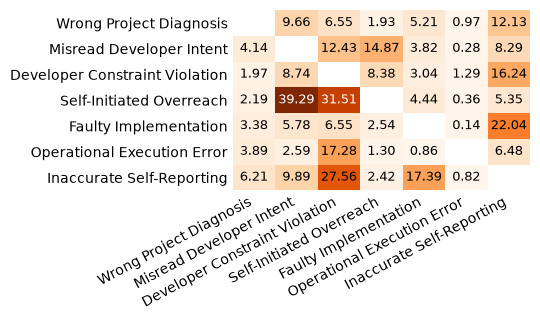

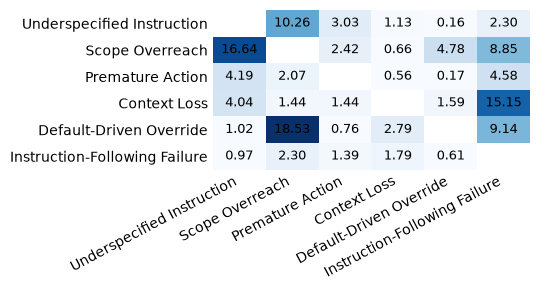

In [4]:
import numpy as np
import matplotlib.pyplot as plt

LABEL_MAP = {
    **{
        f"S{i}": name
        for i, name in enumerate(
            [
                "Wrong Project Diagnosis",
                "Misread Developer Intent",
                "Developer Constraint Violation",
                "Self-Initiated Overreach",
                "Faulty Implementation",
                "Operational Execution Error",
                "Inaccurate Self-Reporting",
            ],
            start=1,
        )
    },
    **{
        f"C{i}": name
        for i, name in enumerate(
            [
                "Underspecified Instruction",
                "Scope Overreach",
                "Premature Action",
                "Context Loss",
                "Default-Driven Override",
                "Instruction-Following Failure",
                "Cannot Determine",
            ],
            start=1,
        )
    },
}


def plot_within_axis_cooccurrence(df, cols, cmap_name, figsize=(5.5, 3.3)):
    if cols[0].startswith("S"):
        indicator = df[cols].fillna(False).astype(int)
    else:
        indicator = df[cols].notna().astype(int)

    heatmap = indicator.T.dot(indicator)
    heatmap = heatmap.div(indicator.sum(axis=0), axis=0).mul(100)

    for col in cols:
        heatmap.loc[col, col] = np.nan

    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad(color="white")

    display_labels = [LABEL_MAP[col] for col in cols]

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(
        heatmap.to_numpy(),
        cmap=cmap,
        aspect="auto",
        vmin=1,
        vmax=np.nanmax(heatmap.to_numpy()),
    )
    ax.set_xticks(range(len(cols)))
    ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(display_labels, rotation=28, ha="right", fontsize=10)
    ax.set_yticklabels(display_labels, fontsize=10)
    ax.tick_params(length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    for i in range(len(cols)):
        for j in range(len(cols)):
            value = heatmap.iat[i, j]
            if pd.isna(value):
                continue
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                color="white" if value >= 30 else "black",
            )

    fig.tight_layout()
    plt.savefig(f"results/cooccurrence_{cols[0][0].lower()}.pdf", bbox_inches="tight")
    plt.show()


plot_within_axis_cooccurrence(
    annotated_misalignments,
    [f"S{i}" for i in range(1, 8)],
    "Oranges",
    (5.5, 3.3),
)

plot_within_axis_cooccurrence(
    annotated_misalignments,
    [f"C{i}" for i in range(1, 7)],
    "Blues",
    (5.5, 3),
)

In [5]:
evidence_tier_counts = {
    f"C{i}": {"direct": 0, "contextual": 0, "speculative": 0, "not_applicable": 0}
    for i in range(1, 8)
}

for cause_col in [f"C{i}" for i in range(1, 8)]:
    for tier in ["direct", "contextual", "speculative", "not_applicable"]:
        evidence_tier_counts[cause_col][tier] = int(
            annotated_misalignments[cause_col].eq(tier).sum()
        )
df_evidence_tier_counts = pd.DataFrame(evidence_tier_counts).T
df_evidence_tier_pcts = (
    df_evidence_tier_counts.div(df_evidence_tier_counts.sum(axis=1), axis=0) * 100
).round(2).astype(str) + "%"

df_evidence_tier_counts["total"] = df_evidence_tier_counts.sum(axis=1)
df_evidence_tier_counts["pct"] = (
    df_evidence_tier_counts["total"] / len(annotated_misalignments) * 100
).round(2).astype(str) + "%"

display(df_evidence_tier_counts, df_evidence_tier_pcts)

,direct,contextual,speculative,not_applicable,total,pct
C1,1672,803,0,0,2475,15.36%
C2,814,712,0,0,1526,9.47%
C3,405,1386,0,0,1791,11.11%
C4,183,510,0,0,693,4.3%
C5,122,268,4,0,394,2.44%
C6,5539,342,0,0,5881,36.49%
C7,0,0,0,4327,4327,26.85%


,direct,contextual,speculative,not_applicable
C1,67.56%,32.44%,0.0%,0.0%
C2,53.34%,46.66%,0.0%,0.0%
C3,22.61%,77.39%,0.0%,0.0%
C4,26.41%,73.59%,0.0%,0.0%
C5,30.96%,68.02%,1.02%,0.0%
C6,94.18%,5.82%,0.0%,0.0%
C7,0.0%,0.0%,0.0%,100.0%


In [6]:
display(
    axis_value_counts_table(annotated_misalignments, "symptom"),
    axis_value_counts_table(annotated_misalignments, "cause"),
    axis_value_counts_table(annotated_misalignments, "damage_severity"),
    axis_value_counts_table(
        annotated_misalignments[annotated_misalignments["damage_locus"].notna()],
        "damage_locus",
    ),
    axis_value_counts_table(annotated_misalignments, "resolution_status"),
    axis_value_counts_table(
        annotated_misalignments[annotated_misalignments["resolver"].notna()], "resolver"
    ),
)

,count,percent,ide_pct,cli_pct
S1. Wrong Project Diagnosis,1863,11.56%,12.78%,9.3%
S2. Misread Developer Intent,4344,26.95%,28.39%,24.31%
S3. Developer Constraint Violation,6178,38.33%,32.26%,49.49%
S4. Self-Initiated Overreach,1644,10.2%,11.5%,7.8%
S5. Faulty Implementation,2872,17.82%,22.89%,8.49%
S6. Operational Execution Error,463,2.87%,2.09%,4.32%
S7. Inaccurate Self-Reporting,3639,22.58%,20.36%,26.66%
S8. Other / Emerging,54,0.34%,0.45%,0.12%


,count,percent,ide_pct,cli_pct
C1. Underspecified Instruction,2475,15.36%,17.65%,11.13%
C2. Scope Overreach,1526,9.47%,10.65%,7.29%
C3. Premature Action,1791,11.11%,11.94%,9.58%
C4. Context Loss,693,4.3%,4.37%,4.18%
C5. Default-Driven Override,394,2.44%,2.63%,2.1%
C6. Instruction-Following Failure,5881,36.49%,29.96%,48.5%
C7. Cannot Determine,4327,26.85%,28.97%,22.94%


,count,percent,ide_pct,cli_pct
DS0. No damage,13,0.08%,0.06%,0.12%
DS1. Effort/trust cost only,14587,90.5%,89.96%,91.49%
"DS2. System damage, easily reversed",1361,8.44%,8.93%,7.56%
"DS3. System damage, hard to reverse",11,0.07%,0.05%,0.11%
DS4. Unobservable,146,0.91%,1.01%,0.72%


,count,percent,ide_pct,cli_pct
DL1. Code/task state,1040,75.8%,83.67%,58.85%
DL2. Project state,254,18.51%,12.7%,31.03%
DL3. Environment/configuration,29,2.11%,2.03%,2.3%
DL4. External state,49,3.57%,1.6%,7.82%


,count,percent,ide_pct,cli_pct
RS1. Resolved,1504,9.33%,8.38%,11.08%
RS2. Unknown,14614,90.67%,91.62%,88.92%


,count,percent,ide_pct,cli_pct
RV1. Agent self-corrected,45,2.99%,2.4%,3.82%
RV2. Agent after pushback,1376,91.49%,90.29%,93.16%
RV3. Developer took over,83,5.52%,7.31%,3.02%


In [7]:
cross_axis_percent_table(annotated_misalignments, "damage_severity", "damage_locus")

,DL1. Code/task state,DL2. Project state,DL3. Environment/configuration,DL4. External state,All
DS0. No damage,NaN,NaN,NaN,NaN,0.0%
DS1. Effort/trust cost only,NaN,NaN,NaN,NaN,0.0%
"DS2. System damage, easily reversed",76.34%,18.37%,2.06%,3.23%,99.2%
"DS3. System damage, hard to reverse",9.09%,36.36%,9.09%,45.45%,0.8%
DS4. Unobservable,NaN,NaN,NaN,NaN,0.0%
All,75.8%,18.51%,2.11%,3.57%,100.0%


In [8]:
cross_axis_percent_table(annotated_misalignments, "symptom", "cause", vis_heatmap=True)

,C1. Underspecified Instruction,C2. Scope Overreach,C3. Premature Action,C4. Context Loss,C5. Default-Driven Override,C6. Instruction-Following Failure,C7. Cannot Determine,All
S1. Wrong Project Diagnosis,8.96%,1.23%,41.01%,6.5%,0.31%,8.86%,33.13%,8.5%
S2. Misread Developer Intent,44.1%,12.57%,4.33%,7.95%,2.8%,19.35%,8.9%,21.12%
S3. Developer Constraint Violation,2.05%,7.3%,2.14%,4.09%,4.91%,73.68%,5.83%,28.87%
S4. Self-Initiated Overreach,14.34%,66.99%,3.5%,1.11%,3.96%,8.58%,1.52%,9.44%
S5. Faulty Implementation,6.68%,2.9%,24.6%,1.7%,0.47%,14.15%,49.5%,13.04%
S6. Operational Execution Error,2.66%,1.43%,27.2%,5.73%,1.02%,25.36%,36.61%,2.13%
S7. Inaccurate Self-Reporting,3.57%,2.3%,9.94%,3.42%,0.78%,31.82%,48.17%,16.68%
S8. Other / Emerging,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,100.0%,0.23%
All,13.54%,11.98%,10.79%,4.43%,2.62%,34.61%,22.03%,100.0%


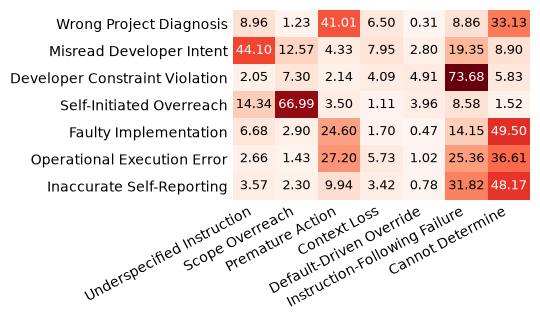

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
from table_utils import cross_axis_counts, _apply_pretty_labels

heatmap = cross_axis_counts(annotated_misalignments, "symptom", "cause")
heatmap = heatmap.drop(index="S8")

heatmap = heatmap.div(heatmap.sum(axis=1), axis=0).mul(100).round(2)
heatmap = _apply_pretty_labels(heatmap, "symptom", "cause")
heatmap.index = [x.split(". ", 1)[1] for x in heatmap.index]
heatmap.columns = [x.split(". ", 1)[1] for x in heatmap.columns]

fig, ax = plt.subplots(figsize=(5.5, 3.3))
im = ax.imshow(heatmap, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(heatmap.columns)))
ax.set_yticks(range(len(heatmap.index)))
ax.set_xticklabels(heatmap.columns, rotation=28, ha="right", fontsize=10)
ax.set_yticklabels(heatmap.index, fontsize=10)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

threshold = heatmap.to_numpy().max() / 2
for i in range(len(heatmap.index)):
    for j in range(len(heatmap.columns)):
        value = heatmap.iat[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="white" if value > threshold else "black",
        )

fig.tight_layout()
fig.savefig(
    Path("results") / "symptom_x_cause_heatmap_compact.pdf",
    bbox_inches="tight",
)
plt.show()

In [10]:
cross_axis_percent_table(
    annotated_misalignments, "symptom", "damage_severity", vis_heatmap=True
)

,DS0. No damage,DS1. Effort/trust cost only,"DS2. System damage, easily reversed","DS3. System damage, hard to reverse",DS4. Unobservable,All
S1. Wrong Project Diagnosis,0.0%,94.74%,4.4%,0.0%,0.86%,8.85%
S2. Misread Developer Intent,0.0%,95.19%,4.56%,0.02%,0.23%,20.63%
S3. Developer Constraint Violation,0.21%,91.47%,6.99%,0.1%,1.23%,29.34%
S4. Self-Initiated Overreach,0.0%,81.2%,16.85%,0.3%,1.64%,7.81%
S5. Faulty Implementation,0.0%,73.26%,24.93%,0.07%,1.74%,13.64%
S6. Operational Execution Error,0.0%,91.36%,7.56%,0.65%,0.43%,2.2%
S7. Inaccurate Self-Reporting,0.0%,94.83%,4.84%,0.03%,0.3%,17.28%
S8. Other / Emerging,0.0%,100.0%,0.0%,0.0%,0.0%,0.26%
All,0.06%,89.84%,9.1%,0.09%,0.91%,100.0%


In [11]:
cross_axis_percent_table(annotated_misalignments, "symptom", "resolver", vis_heatmap=True)

,RV1. Agent self-corrected,RV2. Agent after pushback,RV3. Developer took over,All
S1. Wrong Project Diagnosis,3.14%,90.94%,5.92%,15.73%
S2. Misread Developer Intent,0.0%,95.29%,4.71%,19.79%
S3. Developer Constraint Violation,3.15%,88.01%,8.83%,17.38%
S4. Self-Initiated Overreach,0.74%,85.93%,13.33%,7.4%
S5. Faulty Implementation,1.3%,94.35%,4.35%,25.22%
S6. Operational Execution Error,20.21%,76.6%,3.19%,5.15%
S7. Inaccurate Self-Reporting,2.99%,94.01%,2.99%,9.16%
S8. Other / Emerging,0.0%,100.0%,0.0%,0.16%
All,2.74%,91.34%,5.92%,100.0%
